To visualize the cost function $ J(\theta) $ in linear regression, we can plot the cost as we vary one of the parameters, such as $ \beta_0 $ (intercept) or $ \beta_1 $ (slope), while keeping the other parameter fixed.



## 1. Varying B1 - The Slope
#### Approach:
1. We’ll define a simple linear regression model with a single predictor.
2. Calculate the cost function (Mean Squared Error) for a range of values for one parameter (e.g., $ \beta_1 $) while keeping the other parameter fixed.
3. Plot the cost against the parameter to show the "U-shaped" curve, which will resemble the plot you provided.

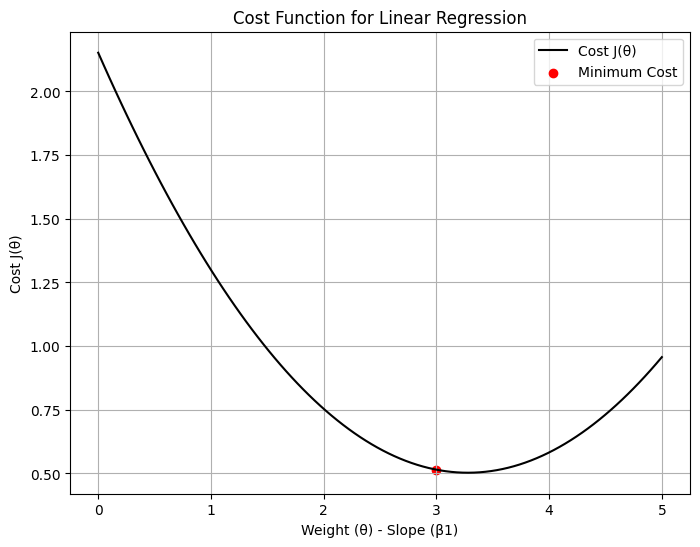

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Define the cost function for linear regression
def compute_cost(X, y, b0, b1):
    m = len(y)
    predictions = b0 + b1 * X
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Generate a range of values for b1 while keeping b0 constant
b1_values = np.linspace(0, 5, 100)  # Range of values for the slope (beta_1)
b0_fixed = 4  # Keep the intercept (beta_0) fixed at 4
cost_values = [compute_cost(X, y, b0_fixed, b1) for b1 in b1_values]

# Plotting the cost function
plt.figure(figsize=(8, 6))
plt.plot(b1_values, cost_values, label="Cost J(θ)", color="black")
plt.scatter([3], [compute_cost(X, y, b0_fixed, 3)], color="red", label="Minimum Cost")
plt.xlabel("Weight (θ) - Slope (β1)")
plt.ylabel("Cost J(θ)")
plt.title("Cost Function for Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


### Explanation:
- **`compute_cost` function**: Calculates the Mean Squared Error (cost) for given values of $ \beta_0 $ and $ \beta_1 $.
- **`b1_values`**: Represents a range of slope values we want to test.
- **Plotting**: We plot `b1_values` (the slope parameter) on the x-axis and the resulting cost on the y-axis to visualize the U-shaped cost function.

### Additional Tips:
- **Change Parameter**: You could try varying $ \beta_0 $ instead, or experiment with both $ \beta_0 $ and $ \beta_1 $ together to create a 3D surface plot.
- **Gradient Descent**: To illustrate gradient descent steps, you could add a loop that iteratively updates $ \beta_1 $ (or $ \beta_0 $) and plots the cost at each step.

## 2. Varying $ \beta_0 $ (the intercept)

Changing the intrcept can also help visualize the effect of the intercept on the cost function in linear regression. Instead of varying $ \beta_1 $ (the slope), we’ll fix $ \beta_1 $ and change $ \beta_0 $ over a range of values, while computing the cost for each value of $ \beta_0 $.

This approach will show how the cost function behaves as we vary the intercept, which can also produce a U-shaped curve.

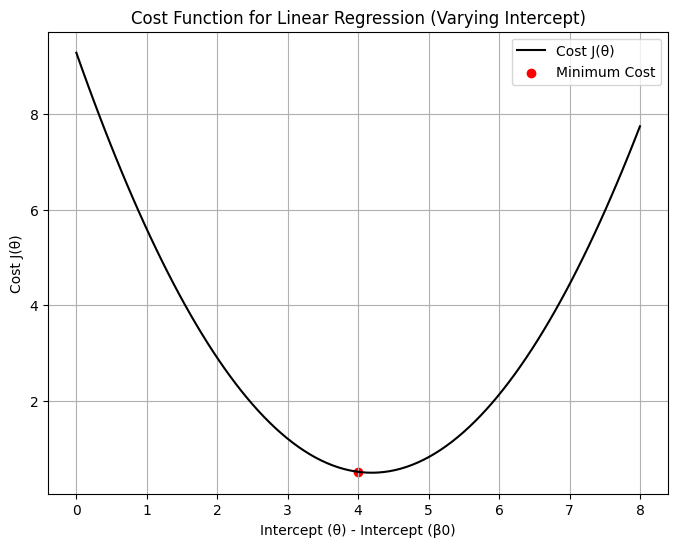

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # True model: y = 4 + 3*X + noise

# Define the cost function for linear regression
def compute_cost(X, y, b0, b1):
    m = len(y)
    predictions = b0 + b1 * X
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Generate a range of values for b0 while keeping b1 constant
b0_values = np.linspace(0, 8, 100)  # Range of values for intercept (beta_0)
b1_fixed = 3  # Keep the slope (beta_1) fixed at 3
cost_values = [compute_cost(X, y, b0, b1_fixed) for b0 in b0_values]

# Plotting the cost function as a function of b0
plt.figure(figsize=(8, 6))
plt.plot(b0_values, cost_values, label="Cost J(θ)", color="black")
plt.scatter([4], [compute_cost(X, y, 4, b1_fixed)], color="red", label="Minimum Cost")
plt.xlabel("Intercept (θ) - Intercept (β0)")
plt.ylabel("Cost J(θ)")
plt.title("Cost Function for Linear Regression (Varying Intercept)")
plt.legend()
plt.grid(True)
plt.show()

### Explanation:
- **`b0_values`**: We create a range of values for the intercept $ \beta_0 $ from 0 to 8. This lets us observe how changing the intercept affects the cost function.
- **Fixed $ \beta_1 $**: We set $ \beta_1 = 3 $, which aligns with the true slope in the data generation (`y = 4 + 3 * X + noise`).
- **Cost Calculation**: We calculate the cost for each value of $ \beta_0 $ while keeping $ \beta_1 $ constant, generating a U-shaped plot of the cost function with respect to $ \beta_0 $.

### Result
This plot will show the cost as a function of the intercept $ \beta_0 $, with a minimum at or near the true intercept (4). This approach illustrates how the cost function changes as we adjust $ \beta_0 $ while holding $ \beta_1 $ constant, giving insights into how gradient descent might converge to an optimal intercept.

## 3. Varying Changing both $ \beta_0 $ and $ \beta_1 $

Creating a 3D surface plot for both $ \beta_0 $ (intercept) and $ \beta_1 $ (slope) is a suitable way to visualize how the cost function behaves as we vary both parameters. This surface plot will show the cost as a function of both $ \beta_0 $ and $ \beta_1 $, helping illustrate how gradient descent might navigate toward the minimum cost.

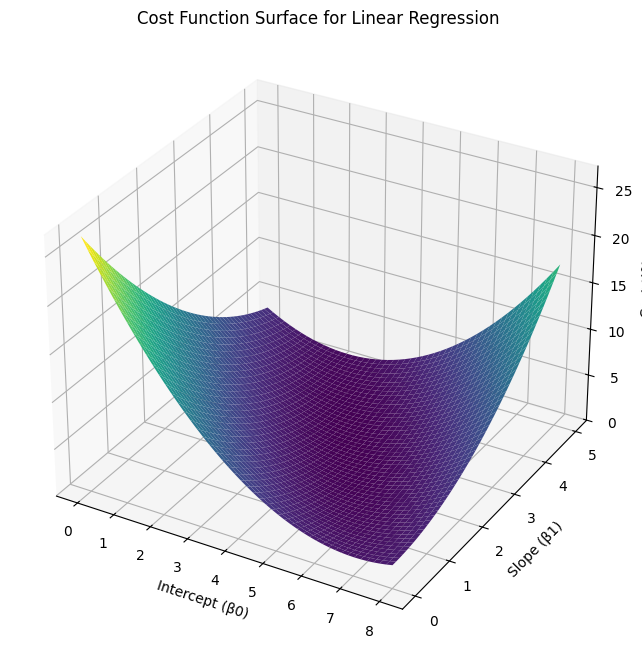

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # True model: y = 4 + 3*X + noise

# Define the cost function for linear regression
def compute_cost(X, y, b0, b1):
    m = len(y)
    predictions = b0 + b1 * X
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Generate a range of values for b0 and b1
b0_values = np.linspace(0, 8, 50)  # Range of values for intercept (beta_0)
b1_values = np.linspace(0, 5, 50)  # Range of values for slope (beta_1)

# Create a meshgrid for b0 and b1
B0, B1 = np.meshgrid(b0_values, b1_values)

# Compute the cost for each combination of b0 and b1
cost_values = np.array([[compute_cost(X, y, b0, b1) for b0 in b0_values] for b1 in b1_values])

# Plotting the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(B0, B1, cost_values, cmap='viridis', edgecolor='none')
ax.set_xlabel('Intercept (β0)')
ax.set_ylabel('Slope (β1)')
ax.set_zlabel('Cost J(θ)')
ax.set_title('Cost Function Surface for Linear Regression')
plt.show()

### Explanation of the Code

1. **Define Parameter Ranges**:
   - We set up a range for $ \beta_0 $ (from 0 to 8) and $ \beta_1 $ (from 0 to 5) to see how the cost changes over these values.

2. **Meshgrid Creation**:
   - `np.meshgrid` creates a grid of $ \beta_0 $ and $ \beta_1 $ values for evaluating the cost function at each combination of parameters.

3. **Cost Calculation**:
   - We use a nested list comprehension to compute the cost for each pair of $ \beta_0 $ and $ \beta_1 $ values, resulting in a matrix of cost values.

4. **3D Surface Plot**:
   - `plot_surface` creates a 3D surface plot, where `B0` and `B1` represent the parameter values and `cost_values` represents the corresponding cost.

### Interpretation of the Plot
- The lowest point (minimum cost) on this surface should be close to the true parameters $ \beta_0 = 4 $ and $ \beta_1 = 3 $.
- This plot provides a visual representation of the "valley" that gradient descent would follow, moving along the slope of the cost function surface toward the minimum.

This 3D plot is helpful for understanding how both the intercept and slope influence the cost and shows why gradient descent converges toward the global minimum.

## Conclusion

Yes, you are absolutely correct! The **cost function** in linear regression is indeed primarily a function of the parameters $ \beta_0 $ (intercept) and $ \beta_1 $ (slope) — not the data $ X $ itself. When we perform linear regression, we aim to **minimize the cost function** by adjusting these parameters, $ \beta_0 $ and $ \beta_1 $, to find the values that minimize the overall error (cost).

### Why the Cost Function is a Function of $ \beta_0 $ and $ \beta_1 $

The cost function $ J(\beta_0, \beta_1) $ is defined as:
\[
J(\beta_0, \beta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( y^{(i)} - (\beta_0 + \beta_1 X^{(i)}) \right)^2
\]

In this equation:
- $ m $ is the number of data points,
- $ y^{(i)} $ and $ X^{(i)} $ are fixed values from the dataset,
- $ \beta_0 $ and $ \beta_1 $ are the parameters we adjust to minimize $ J $.

Since $ X $ and $ y $ are fixed values (observed data points), **the cost function essentially becomes a function of $ \beta_0 $ and $ \beta_1 $**. By altering $ \beta_0 $ and $ \beta_1 $, we can change the predictions $ \beta_0 + \beta_1 X^{(i)} $, which in turn affects the cost.

### Minimization Process

The goal of **gradient descent** (or any optimization method used for linear regression) is to iteratively adjust $ \beta_0 $ and $ \beta_1 $ to reduce the cost:
- We calculate the **gradient** of the cost function with respect to $ \beta_0 $ and $ \beta_1 $.
- By moving in the direction opposite to the gradient, we decrease the cost until it reaches a minimum.

So, the **minimization process** involves only altering $ \beta_0 $ and $ \beta_1 $, while $ X $ and $ y $ remain fixed.

### Summary

- The cost function $ J(\beta_0, \beta_1) $ is indeed a function of $ \beta_0 $ and $ \beta_1 $.
- Minimization is achieved by adjusting $ \beta_0 $ and $ \beta_1 $, with the data $ X $ and $ y $ held constant.
- The goal of this process is to find the values of $ \beta_0 $ and $ \beta_1 $ that minimize the cost function, effectively "fitting" the model to the data. 

This is why we plot the cost function as a surface over $ \beta_0 $ and $ \beta_1 $ — because these are the variables that we control to achieve minimization.